In [1]:
import importlib

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import seaborn as sns
import pandas as pd


from src.service.util import Util


dataset = pd.read_csv("/Users/macbookpro/PycharmProjects/projet_credit_risk_modeling/data/processed/credit_risk_cleansed_dataset_v0.csv")

dataset.head()



,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_groupe
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.100000,N,2,20-26
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.570000,N,3,26-30
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.530000,N,2,20-26
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.643382,Y,4,26-30
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.250000,N,2,20-26


In [2]:
util = Util(dataset = dataset)

# Univarie des Features quantitative

PERSON_AGE

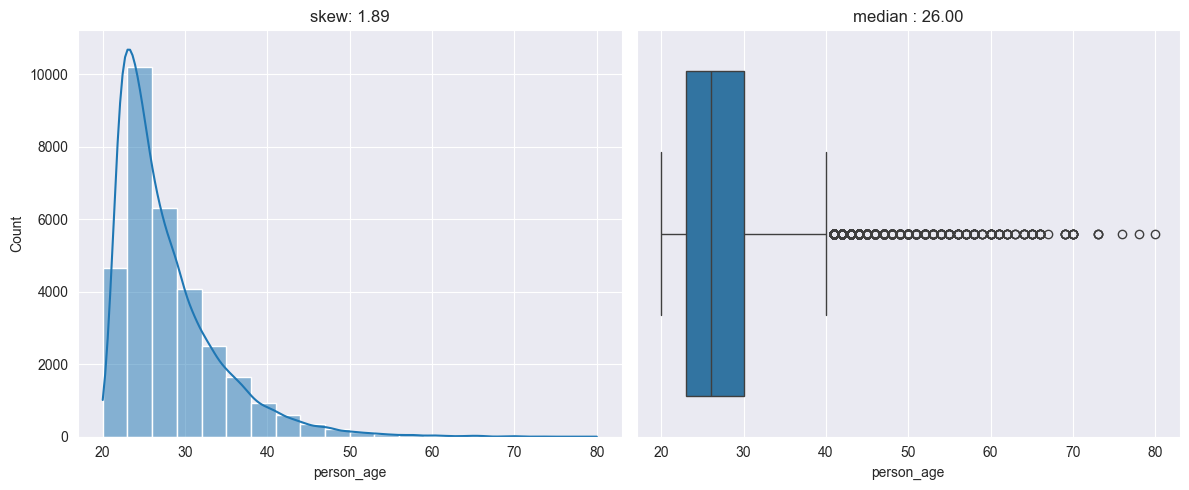

In [3]:
util.global_view('person_age')

In [4]:
dataset['person_age'].describe()

count    31833.000000
mean        27.780951
std          6.216500
min         20.000000
25%         23.000000
50%         26.000000
75%         30.000000
max         80.000000
Name: person_age, dtype: float64

In [5]:
dataset['person_age'].mode()

0    23
Name: person_age, dtype: int64

transformation log(x)

In [6]:
dataset['log_person_age'] = np.log(dataset['person_age'])

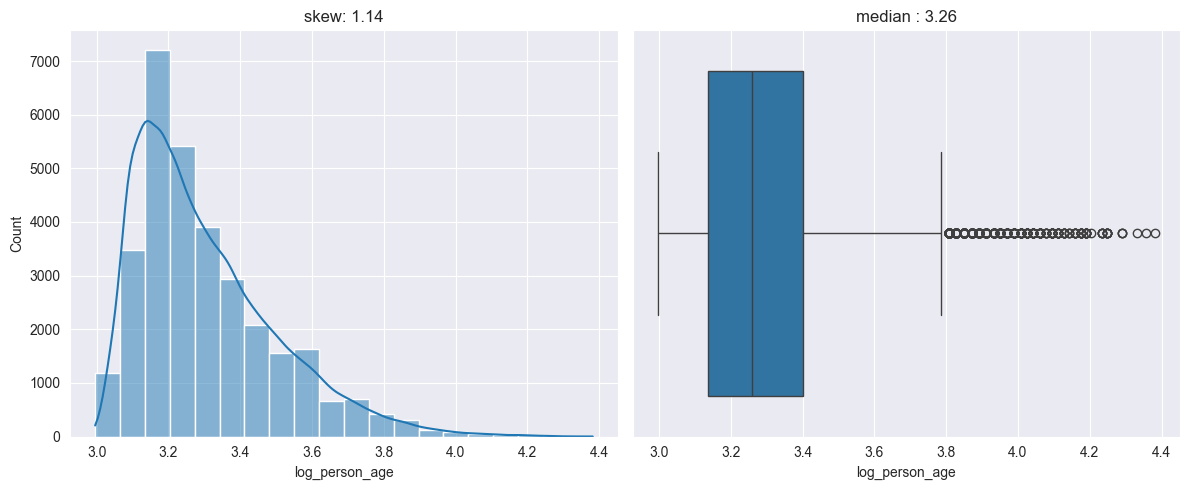

In [7]:
util.global_view('log_person_age')

obs :

      - Presence des outliers dans la distribution
      - on fait fasse a une population assez jeune dont la majorite ont entre [ 20 , 30 ] ans, l'age recurrent est de 23 ans
      - on a une asymetrie forte avec un skew > 1

      - on a realiser une transformation pour attenuer l'effet des ages sur le model

PERSON_INCOME

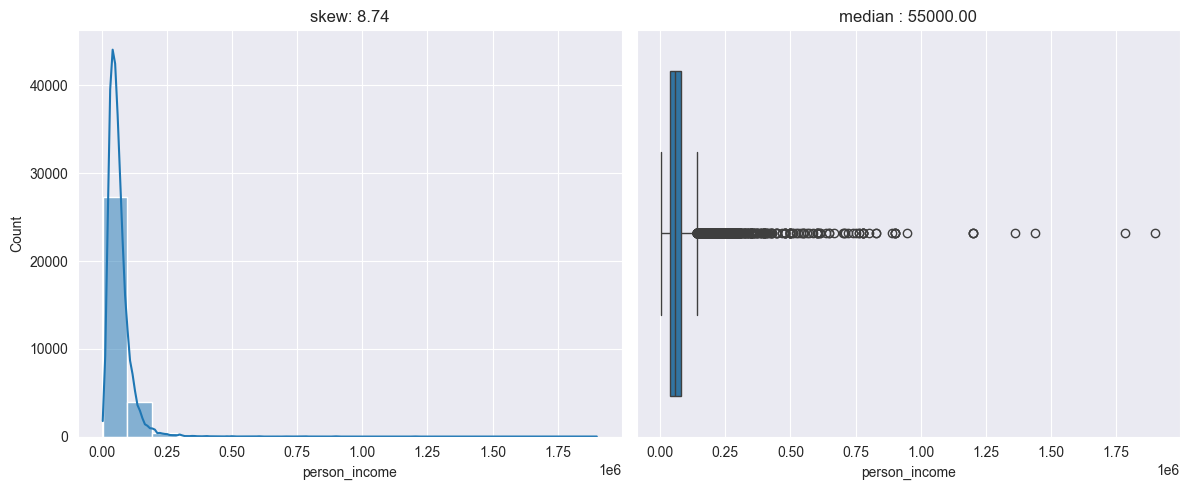

In [8]:
util.global_view('person_income')

In [9]:
dataset['person_income'].describe()

count    3.183300e+04
mean     6.577489e+04
std      5.163273e+04
min      4.000000e+03
25%      3.840000e+04
50%      5.500000e+04
75%      7.905000e+04
max      1.900000e+06
Name: person_income, dtype: float64

In [10]:
dataset['person_income_group'],bins  = pd.qcut(dataset['person_income'], q=4, retbins=True, labels=['FAIBLE','MOYEN','HAUT','FORT'])

In [11]:
dataset.groupby('person_income_group')['person_income'].count()

person_income_group
FAIBLE    7987
MOYEN     8058
HAUT      7833
FORT      7955
Name: person_income, dtype: int64

transformation log(x)

In [12]:
dataset['log_person_income'] = np.log(dataset['person_income'])

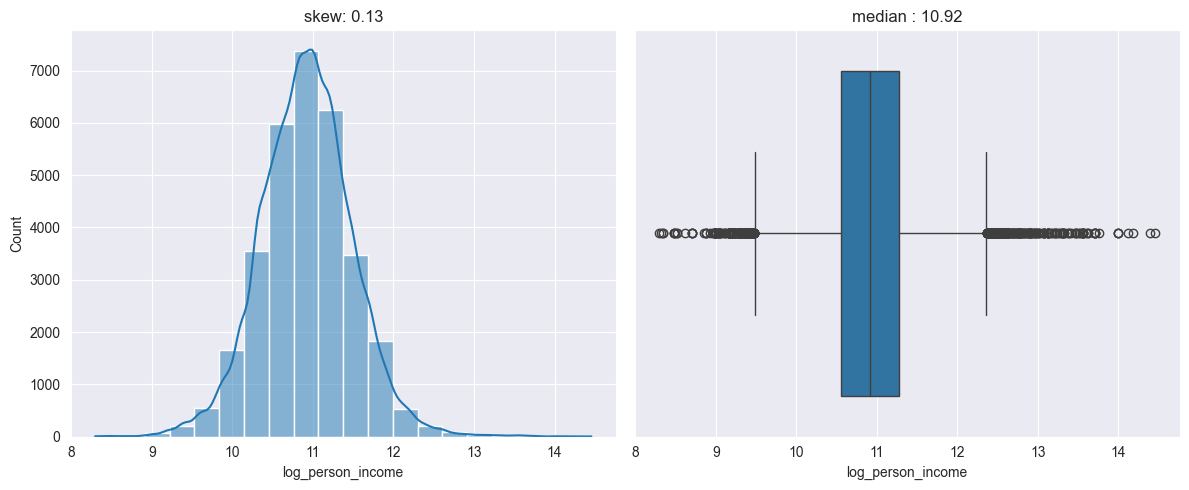

In [13]:
util.global_view('log_person_income')

Obs:

    - les valeur extreme constituent 6% des distribution
    - les faible revenu ne depasse  pas 38400
    - beaucoup d'observation sont dans la categorie MOYEN


    - asymetrie extreme dans la distribution avec un skew > 1
    - la transformation demontre une distribution symetrique

PERSON_EMP_LENGTH

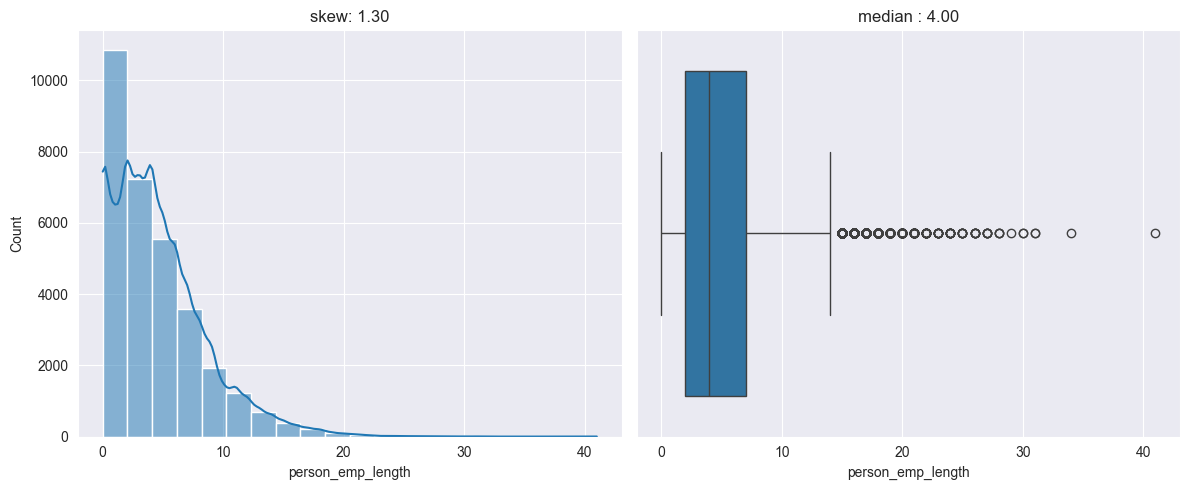

In [14]:
util.global_view('person_emp_length')

In [15]:
see = dataset.copy()
see['person_emp_length_group'],bins  = pd.qcut(see['person_emp_length'], q=4, retbins=True, labels=['FAIBLE','MOYEN','HAUT','FORT'])

see.groupby('person_emp_length_group')['person_emp_length'].count()/dataset.shape[0]

person_emp_length_group
FAIBLE    0.341312
MOYEN     0.226903
HAUT      0.238212
FORT      0.193573
Name: person_emp_length, dtype: float64

Obs:

    - la grande majorite des observation presente tres peu d'experienc moins de 10 ans
    - pour etre plus precis, 34% ont une experience d'age  inferieur a 4 ans

    -  la distribution est symetrique avec un skew sensiblement eleve

LOAN_AMNT

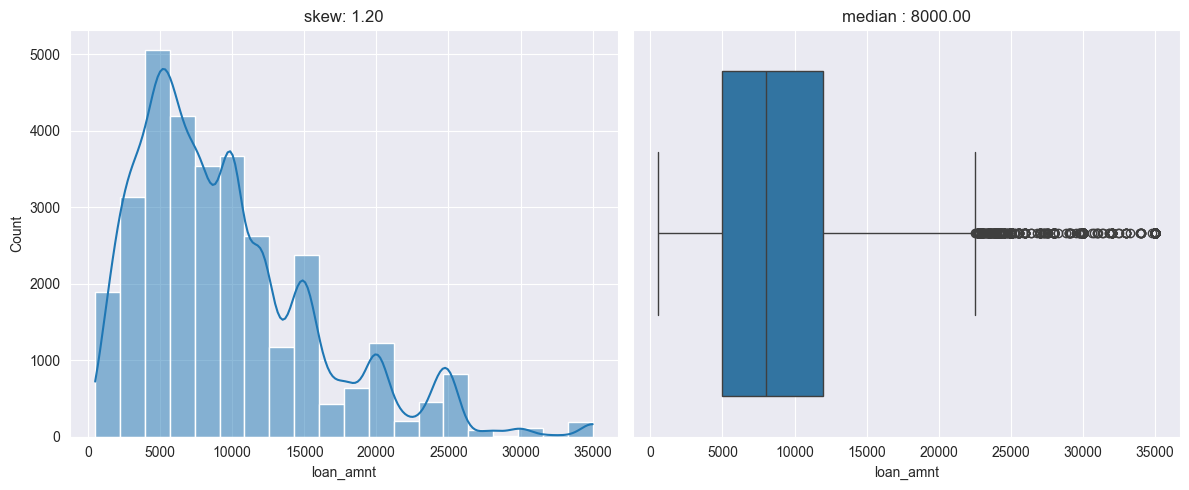

In [16]:
util.global_view('loan_amnt')

In [17]:
dataset['loan_amnt'].quantile([0.25,0.5,0.75,0.99,1])

0.25     5000.0
0.50     8000.0
0.75    12000.0
0.99    30000.0
1.00    35000.0
Name: loan_amnt, dtype: float64

Obs:

    - la tendance est celle d'avoire des pret au alentour de  [ 5000 , 1000]

    - distribution left skewed

    - asymetrie assez faible

LOAN_INT_RATE

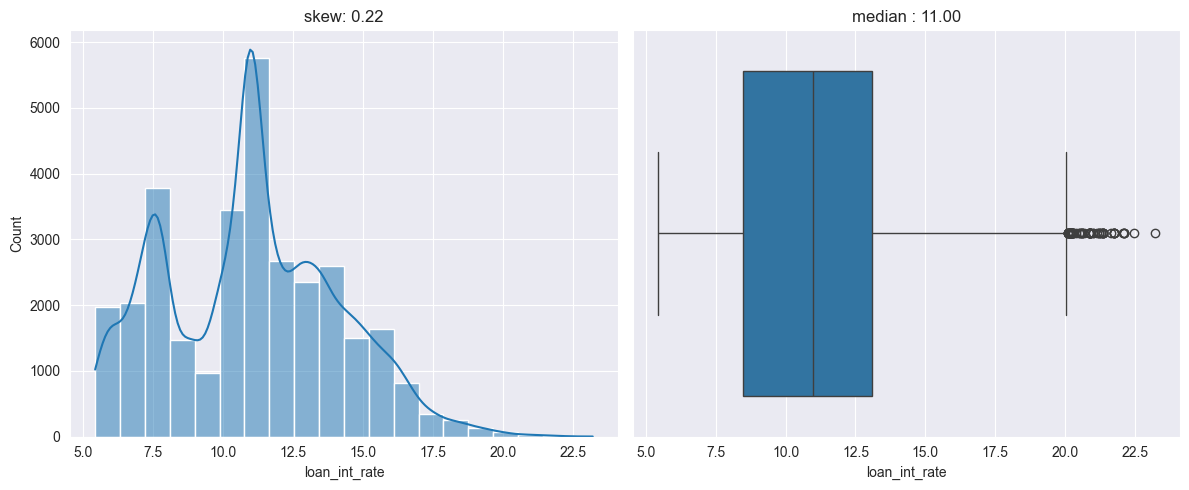

In [18]:
util.global_view('loan_int_rate')

In [19]:
util.binsFrom_hist(feature='loan_int_rate')

,intervalle,borne_gauche,borne_droite,frequence,pct
6,[10.76 - 11.65],10.76,11.65,5763,18.10
2,[7.20 - 8.09],7.20,8.09,3780,11.87
5,[9.87 - 10.76],9.87,10.76,3455,10.85
7,[11.65 - 12.54],11.65,12.54,2679,8.42
9,[13.43 - 14.32],13.43,14.32,2597,8.16
8,[12.54 - 13.43],12.54,13.43,2351,7.39
1,[6.31 - 7.20],6.31,7.20,2038,6.40
0,[5.42 - 6.31],5.42,6.31,1968,6.18
11,[15.21 - 16.10],15.21,16.10,1630,5.12
10,[14.32 - 15.21],14.32,15.21,1501,4.72


In [20]:
util.probdensity('loan_int_rate', law='log-normal', upper_born=11.65, lower_born=10.76)

np.float64(0.11327395338597213)

In [21]:
dataset.loan_int_rate.describe()

count    31833.000000
mean        11.013568
std          3.080124
min          5.420000
25%          8.490000
50%         10.995555
75%         13.110000
max         23.220000
Name: loan_int_rate, dtype: float64

Obs:

        - le taux d'interet moyen est de 11%
        - 18% des observation ont des taux d'interet compis entre  [10, 11] et la probabilite qu'une observeation tombe dans cette interval est seulment de
          11% ce qui temoigne la dispersion des donnees dans cette distribution, les taux d'interet sont tres disperser, cela limite notre capacite a dire
          quel taux est applique a quel typed'individu

        - les tres haut taux d'interet sont compris entre [13,23]

        - La distribution est  a un skew < 0.22, une asymetri faible

        Question:
            - quel est la moyene des taux d'interte applique a une classe de population
            - pour une classe de taux [Petit, moyen , moyen-haut , haut ] , quel est le pourcentage de defaut ?         (localisation )
            - quel statu de pret pour ceux qui ont le taux d'interet moyen


LOAN_PERCENT_INCOME

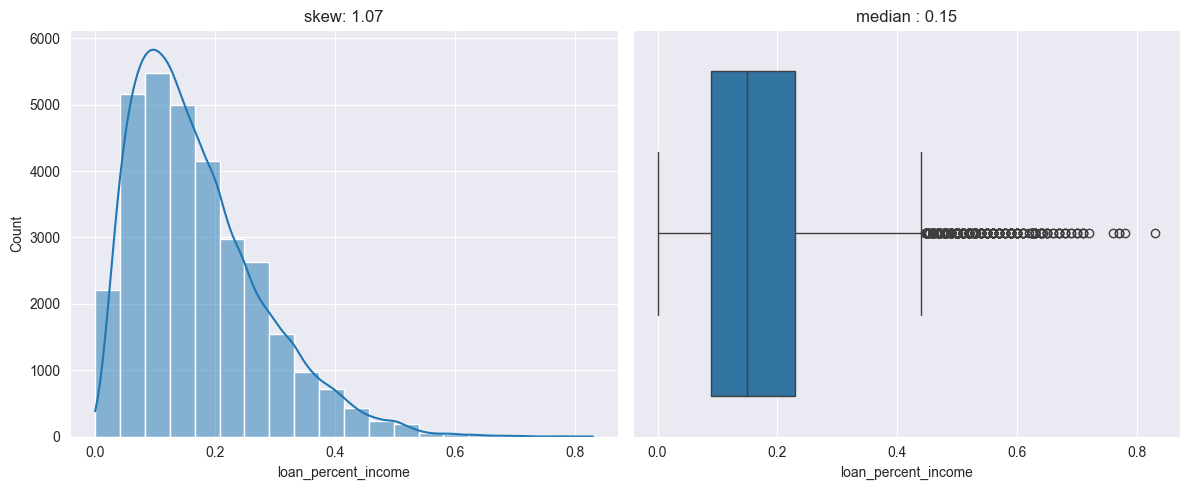

In [22]:
util.global_view(feature='loan_percent_income')


In [23]:
util.binsFrom_hist(feature='loan_percent_income')

,intervalle,borne_gauche,borne_droite,frequence,pct
2,[0.08 - 0.12],0.0830,0.1245,5479,17.21
1,[0.04 - 0.08],0.0415,0.0830,5163,16.22
3,[0.12 - 0.17],0.1245,0.1660,4996,15.69
4,[0.17 - 0.21],0.1660,0.2075,4159,13.07
5,[0.21 - 0.25],0.2075,0.2490,2972,9.34
6,[0.25 - 0.29],0.2490,0.2905,2631,8.27
0,[0.00 - 0.04],0.0000,0.0415,2208,6.94
7,[0.29 - 0.33],0.2905,0.3320,1552,4.88
8,[0.33 - 0.37],0.3320,0.3735,968,3.04
9,[0.37 - 0.41],0.3735,0.4150,710,2.23


In [24]:
dataset.loan_percent_income.describe()

count    31833.000000
mean         0.170430
std          0.107068
min          0.000000
25%          0.090000
50%          0.150000
75%          0.230000
max          0.830000
Name: loan_percent_income, dtype: float64

Obs :

    - la part des pret dans les revenu contitue en moyenne 15 % pour les oobservation
    - pret de 50 % des observation on des part de pret dans les revenu  qui tombe entre [ 4, 20 ]
    -

    Question:
        - pour les observation qui tombe dans [4, 20 ] determiner si les revenu sont consequent , est ce que c'est du au fait que les profile sont fragile ?
          determiner leur moyenne de revenu et les intension de pret, cela donne ses indication sur le comportement

        - pour les observation dans la moyen quel est leur statu de defaut

        - pour chaque class de la part de pret quel indicateur de stabilite ?
                -  exemple: pour ceux localise en dessous de 9 % quel stabilite ?

In [25]:
dataset.drop('person_income_group', axis=1, inplace=True)

In [26]:
dataset.drop('age_groupe', axis=1, inplace=True)


In [27]:
dataset.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'log_person_age', 'log_person_income'],
      dtype='str')

CB_PERSON_CRED_HIST_LENGTH

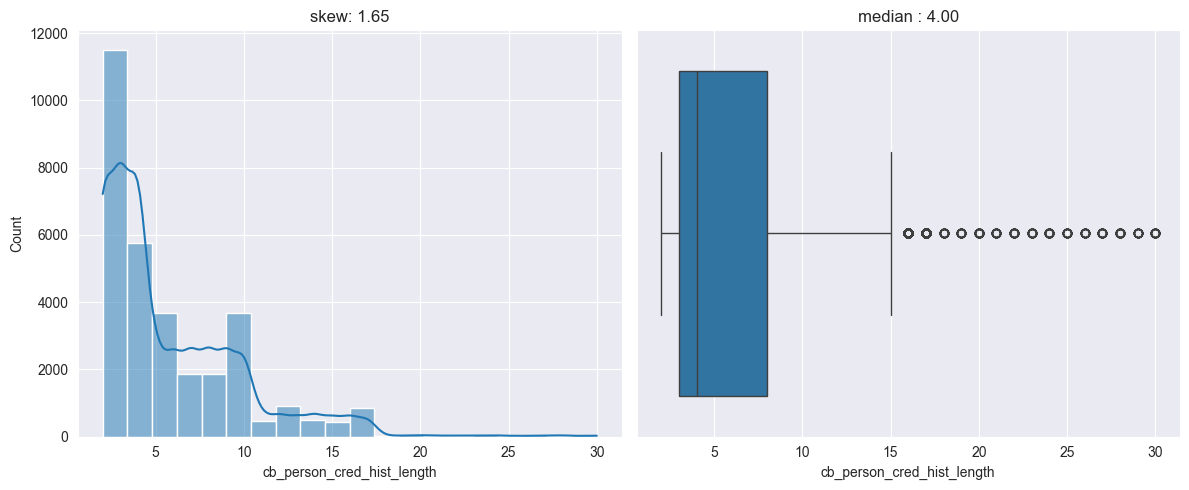

In [28]:
util.global_view('cb_person_cred_hist_length')

In [29]:
dataset.cb_person_cred_hist_length.describe()

count    31833.000000
mean         5.839286
std          4.070679
min          2.000000
25%          3.000000
50%          4.000000
75%          8.000000
max         30.000000
Name: cb_person_cred_hist_length, dtype: float64

In [30]:
util.binsFrom_hist('cb_person_cred_hist_length')

,intervalle,borne_gauche,borne_droite,frequence,pct
0,[2.00 - 3.40],2.0,3.4,11510,36.16
1,[3.40 - 4.80],3.4,4.8,5773,18.14
5,[9.00 - 10.40],9.0,10.4,3684,11.57
2,[4.80 - 6.20],4.8,6.2,3680,11.56
4,[7.60 - 9.00],7.6,9.0,1876,5.89
3,[6.20 - 7.60],6.2,7.6,1866,5.86
7,[11.80 - 13.20],11.8,13.2,921,2.89
10,[16.00 - 17.40],16.0,17.4,857,2.69
8,[13.20 - 14.60],13.2,14.6,491,1.54
6,[10.40 - 11.80],10.4,11.8,460,1.45


Obs:

        - La tendance est celle de voire que les observation ont en moyen 4 credit dans l'historique ( ceci est un indicateur de fiabilite )

        - asymetrie a droite

        Quetion:
            - ceux a qui on attribuer des credit est ce parce qu'il ont beaucoup de revenu, est ce qu'il prenne pret faible qui ne constitue qu'un petit pourcentge des revenu
            - est ce parceque ces gens ont une vie  stable ( experience de travaille ) pas de dette
            - En gros A qui on attribu le credit ?


PERSON_HOME_OWNERSHIP

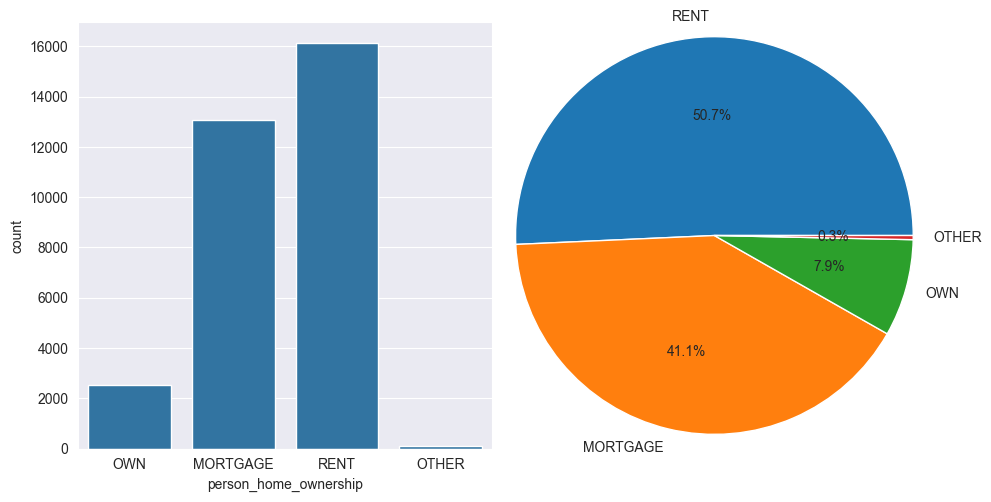

In [31]:
util.visualize_cat('person_home_ownership')


In [32]:
dataset.person_home_ownership.describe()

count     31833
unique        4
top        RENT
freq      16144
Name: person_home_ownership, dtype: object

Obs:

    - les Observation  en location sont plus frquente dans la distribution  50% , suivis par ceux qui ont un pret hypotecaire 41%


    Question :
        - quel est la frequence de defaut de ceux qui sont en location et ceux qui ont un pret hypotecaire et ceux des owner ?
        - la combinaison revenu eleve et own , probabilite de defaut

LOAN_INNTENT

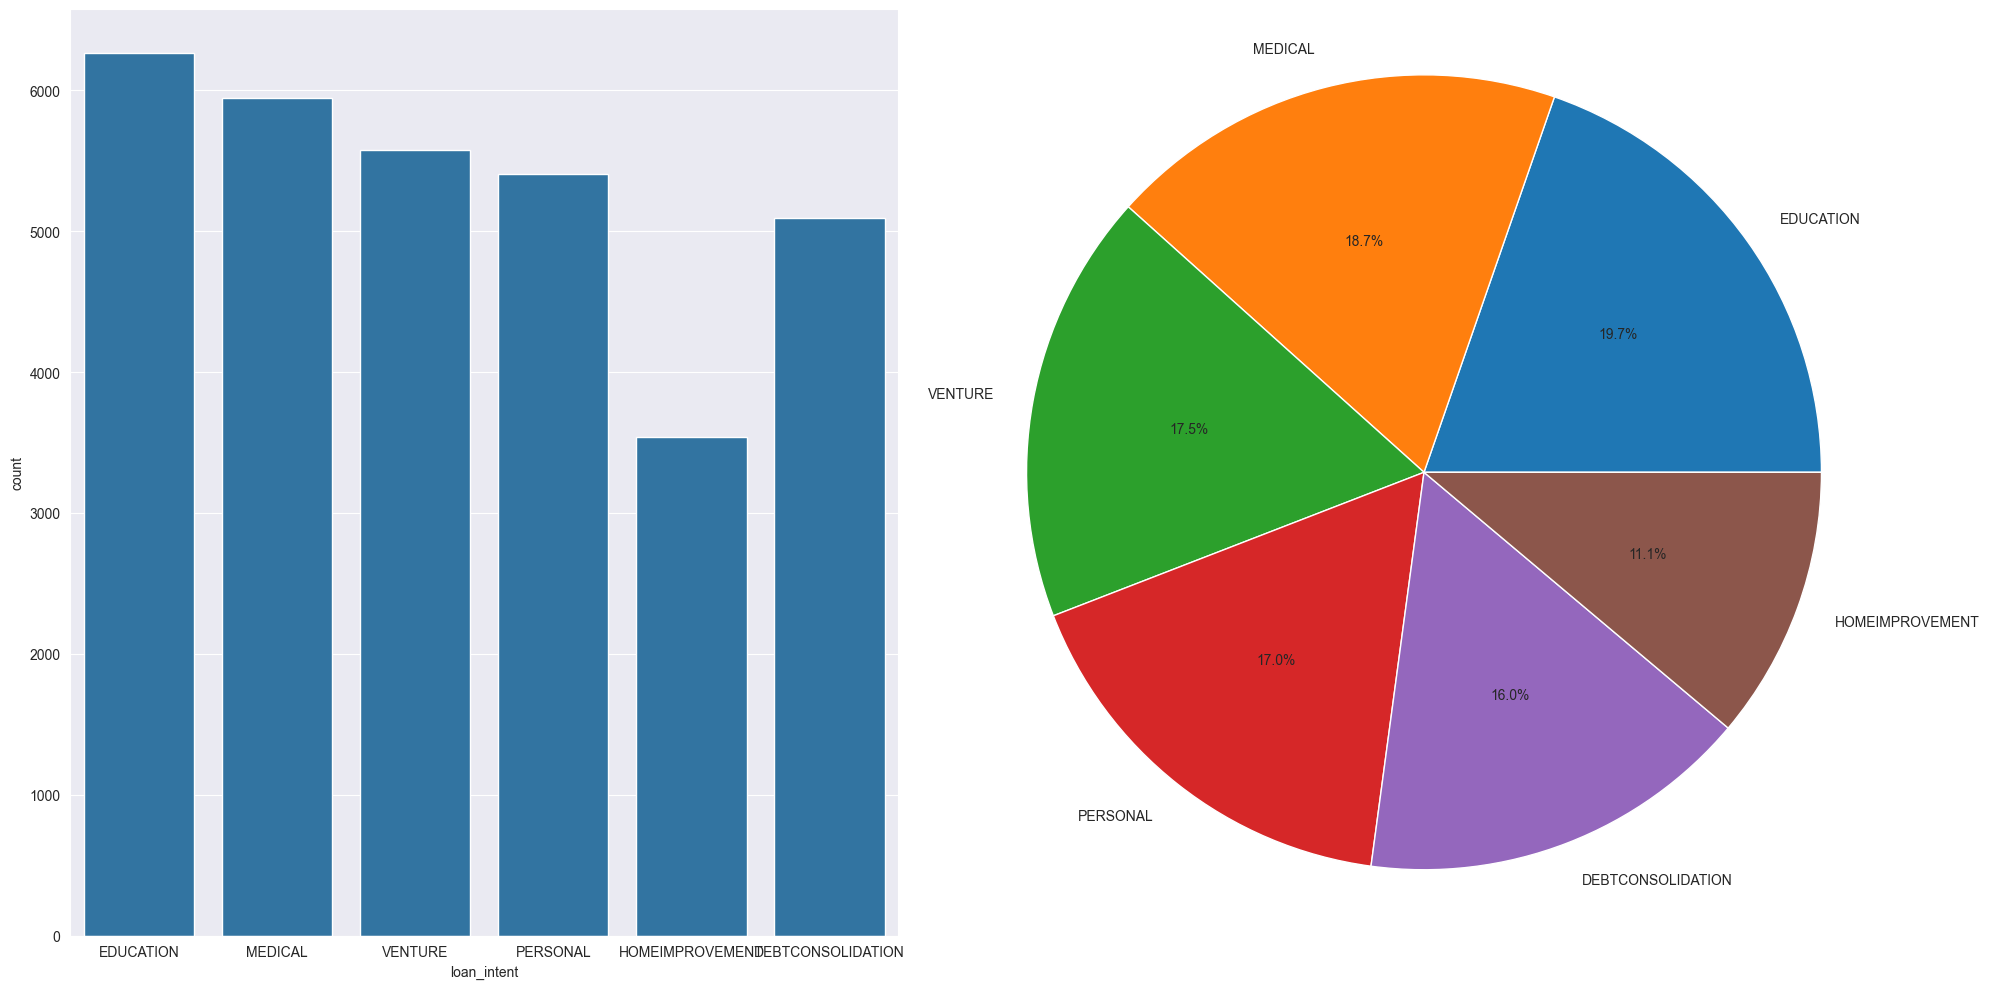

In [33]:
util.visualize_cat('loan_intent',figsize = (20,10))

Obs:

    - les observation sont assez distribuer dans les groupe, mais ceux qui emprunte pour des raison d'education se demarque avec 19,7 % des marges


    Question :
        - qui sont ceux qui ont une grande frequence de defaut ?
        - ceux qui parte en education quel est leur moyenne de revenu et quel moyen d'age ?

LOAN_GRADE

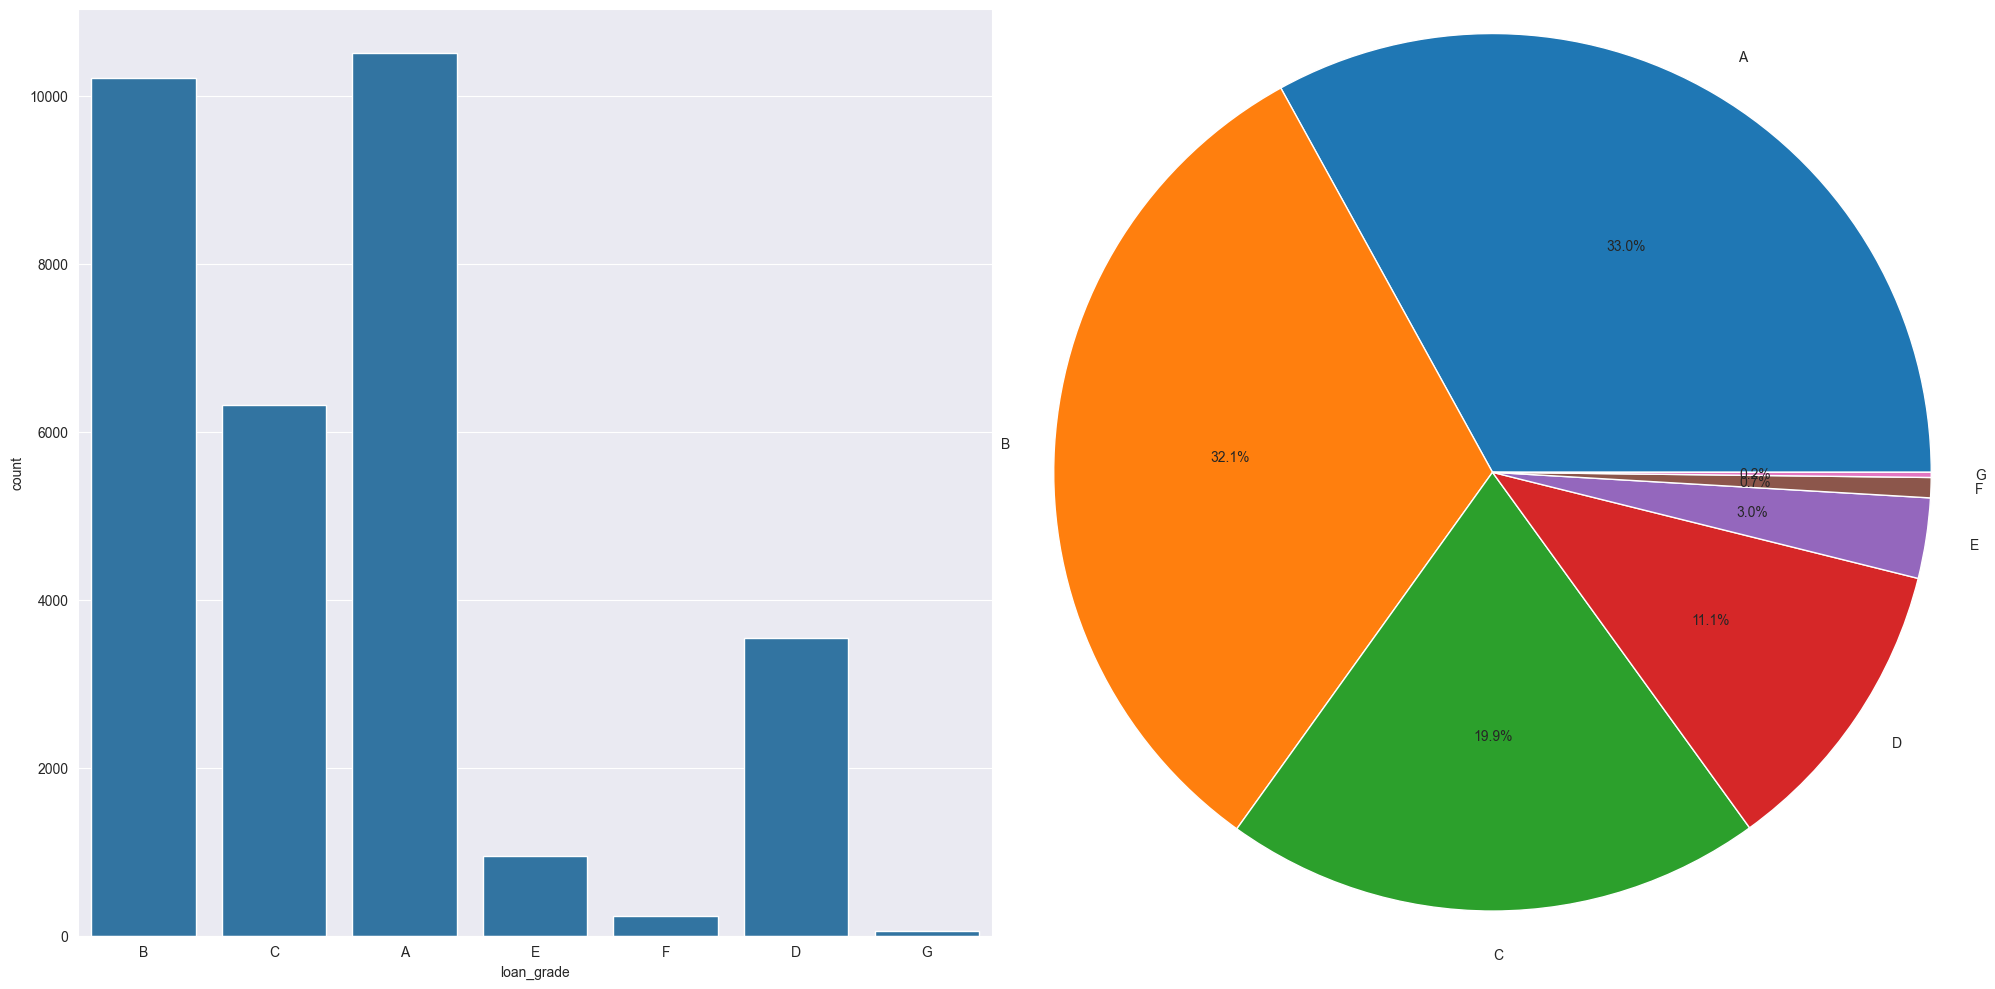

In [34]:
util.visualize_cat('loan_grade', figsize = (20,10))

Obs:

    - 11% des observation ont une notation de pret egale a B

    Question:
        - quel est la moyene de revenu de ceux qui ont une mauvaise note ?
        - est la par du pret dans les revenu qui influence la note de credit ?
        - on t'il un defaut precedent ?
        - si tu as une pars de pret a plus de 30% dans les revenu da chaque class [Petit, moyen , haut] que note de credit ? et quel statu de credit ?

        - une combinaison NOte D ,

In [35]:
dataset.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length',
       'log_person_age', 'log_person_income'],
      dtype='str')

LOAN_STATUS

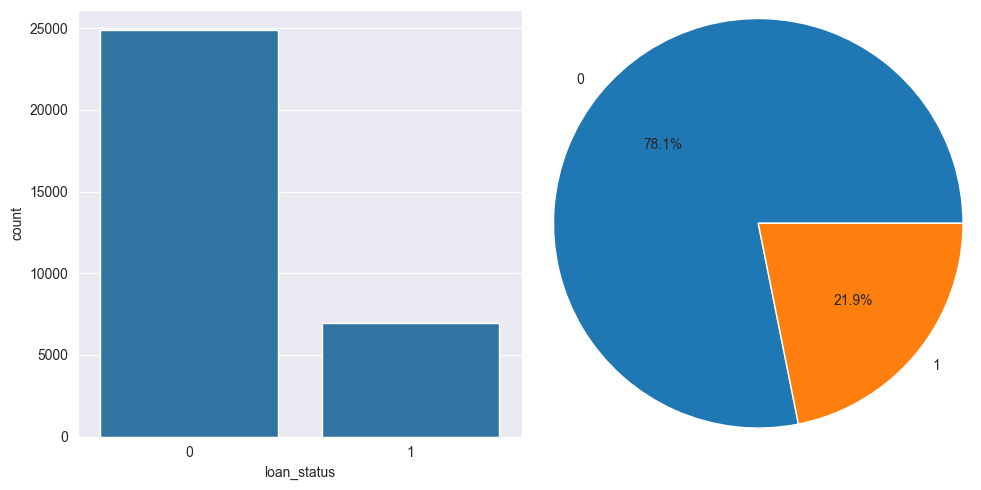

In [36]:
util.visualize_cat('loan_status')

Obs:

    - seulement 21% des observaton sont en situation de defaut

    Question:
        - ceux aui ont des revenu eleve, ont il des part de pret consequen ? (defaut)
        - Si on retient ces indicateur ( stabilite [ revenu ] capcite [ pourcentage de pret dans les revenue ] , fiablite [ nombre de pret, presence defaut ] ) et qu'on observe
          les individudis en fonction d'un feature soit age, sois un autre on peut se faire une idee sur la tendance des defaut

CB_PERSON_DEFAULT_ON_FILE

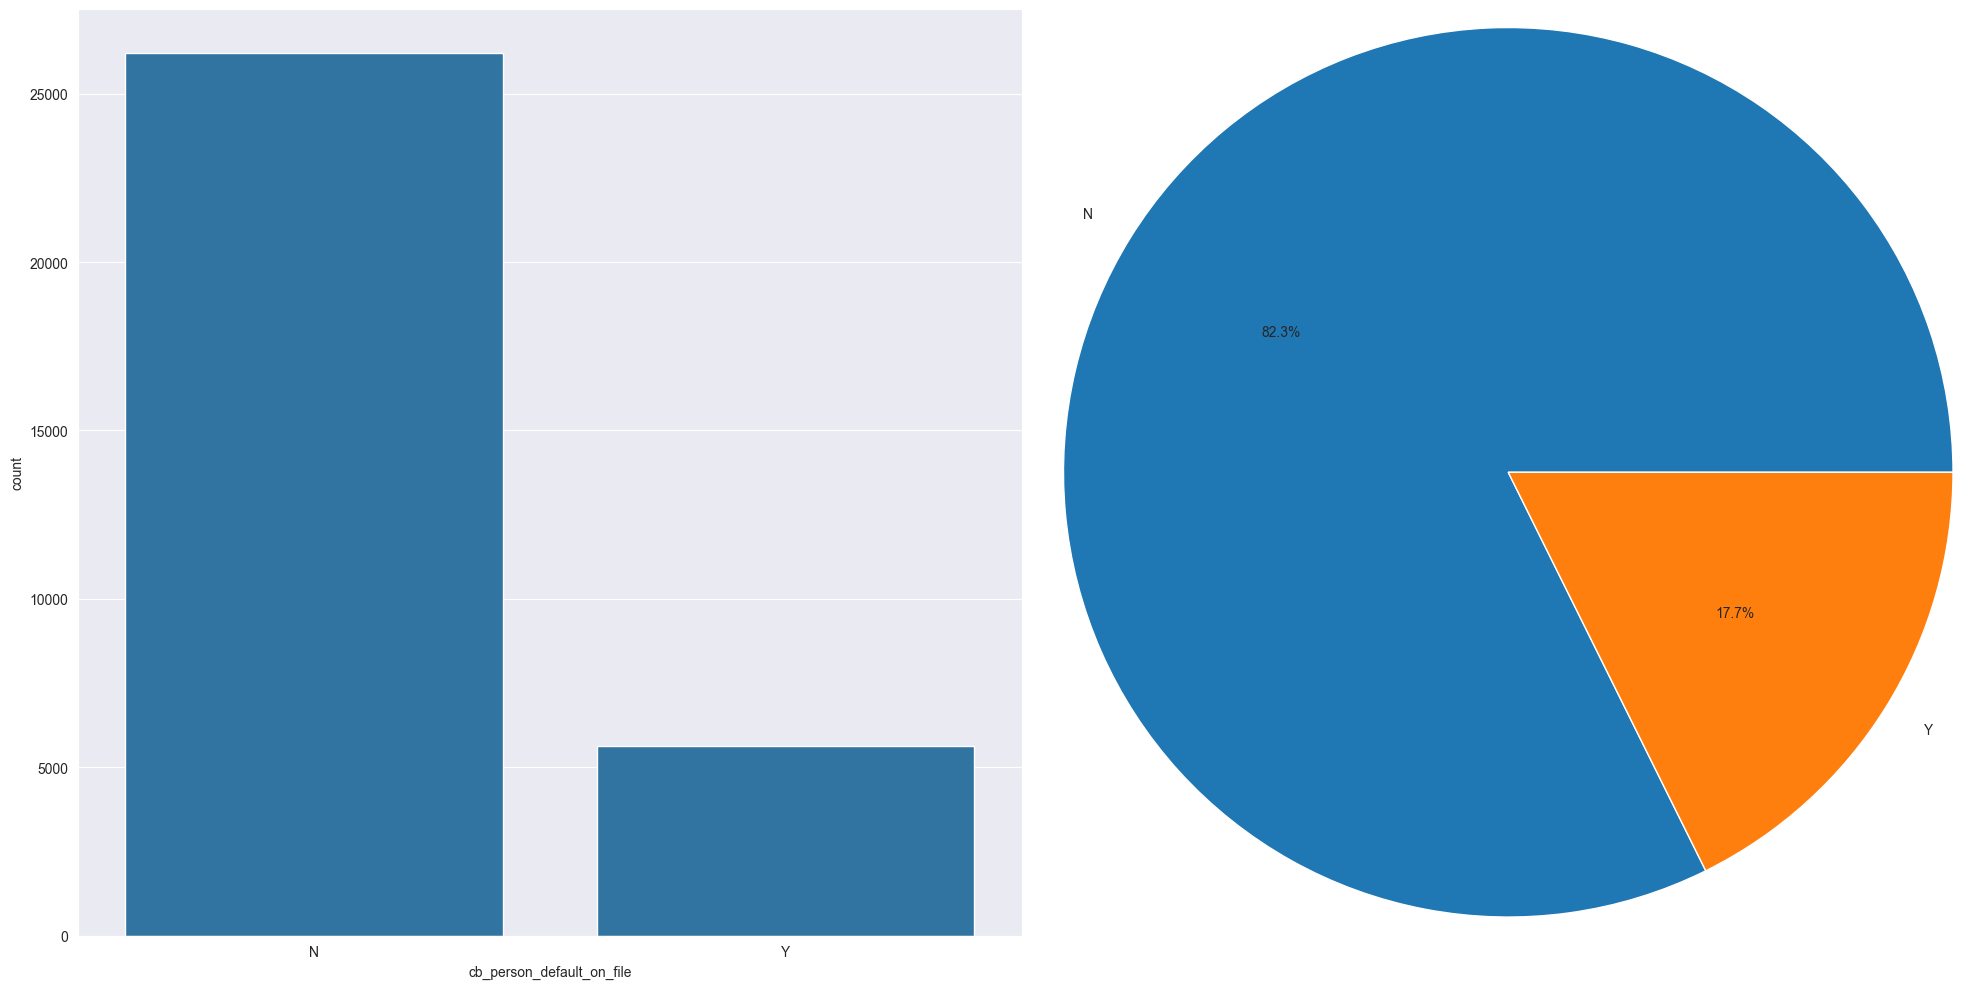

In [37]:
util.visualize_cat('cb_person_default_on_file', figsize = (20,10))

In [39]:
dataset

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,log_person_age,log_person_income
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.100000,N,2,3.044522,9.169518
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.570000,N,3,3.218876,9.169518
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.530000,N,2,3.135494,11.089805
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.643382,Y,4,3.178054,10.904119
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.250000,N,2,3.044522,9.200290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31828,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.110000,N,30,4.043051,10.878047
31829,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.150000,N,19,3.988984,11.695247
31830,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.460000,N,28,4.174387,11.238489
31831,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.100000,N,26,4.025352,11.918391


Extraction


In [42]:
dataset.drop('person_income', axis=1, inplace=True)

In [43]:
dataset.drop('person_age', axis=1, inplace=True)

In [44]:
dataset.to_csv('/Users/macbookpro/PycharmProjects/projet_credit_risk_modeling/data/processed/credit_risk_cleansed_inunivariate_analysis_v0.csv',sep=',',index=False)